# HFSS Driven Modal Simulation of an Interdigital Capacitor

This notebook demonstrates how to set up and run a driven modal (S-parameter)
simulation of an interdigital capacitor using PyAEDT (Ansys HFSS Python interface).

Driven modal analysis computes scattering parameters (S-parameters) of structures
with ports, enabling characterization of coupling capacitance, insertion loss,
and frequency-dependent behavior.

**Prerequisites:**
- Ansys HFSS installed (requires license)
- Install hfss extras: `uv sync --extra hfss` or `pip install qpdk[hfss]`

**References:**
- PyAEDT Documentation: https://aedt.docs.pyansys.com/
- HFSS Driven Modal Examples: https://examples.aedt.docs.pyansys.com/
- Interdigital Capacitor Theory: {cite:p}`leizhuAccurateCircuitModel2000`

## Setup and Imports

In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing quantum-rf-pdk...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[models] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
    ])

In [2]:
import os
import tempfile
import time
from pathlib import Path

import gdsfactory as gf
import matplotlib.pyplot as plt
import numpy as np
from ansys.aedt.core import Hfss, Q3d, settings
from IPython.display import Image, display

from qpdk import PDK
from qpdk.cells.capacitor import interdigital_capacitor
from qpdk.cells.waveguides import straight_open
from qpdk.config import PATH
from qpdk.models.capacitor import interdigital_capacitor_capacitance_analytical
from qpdk.models.cpw import cpw_ep_r_from_cross_section
from qpdk.simulation import HFSS, Q3D, prepare_component_for_aedt
from qpdk.tech import coplanar_waveguide

PDK.activate()

# Create an interdigital capacitor
# This design has 6 fingers with 20µm finger length
cpw_width, cpw_gap = 10, 6
cross_section = coplanar_waveguide(width=cpw_width, gap=cpw_gap)
idc_component = interdigital_capacitor(
    fingers=6,  # Number of interleaved fingers
    finger_length=20.0,  # Length of each finger in µm
    finger_gap=2.0,  # Gap between adjacent fingers in µm
    thickness=5.0,  # Finger width in µm
    cross_section=cross_section,
)

# Attach straight open waveguides to the ports to provide a feedline
# for the lumped ports in HFSS.
c = gf.Component(name="idc_with_feeds")
idc_ref = c << idc_component
open_wvg = straight_open(length=5, cross_section=cross_section)

# Connect feedlines to both ports
feed1 = c << open_wvg
feed1.connect("o1", idc_ref.ports["o1"])
c.add_port("o1", port=feed1.ports["o2"])

feed2 = c << open_wvg
feed2.connect("o1", idc_ref.ports["o2"])
c.add_port("o2", port=feed2.ports["o2"])

# Use the combined component for the rest of the notebook
idc_component = c

# Visualize the component
idc_component.show()
print(f"Interdigital capacitor bounding box: {idc_component.bbox}")
print(f"Number of ports: {len(idc_component.ports)}")
for port in idc_component.ports:
    print(f"  {port.name}: center={port.center}, orientation={port.orientation}°")

## Estimate Capacitance

Before running the full-wave simulation, we can estimate the mutual capacitance
using the analytical conformal mapping model for interdigital capacitors
{cite:p}`igrejaAnalyticalEvaluationInterdigital2004`.

For a structure with $n$ fingers of width $w$, gap $g$, and overlap length $L$,
the metallization ratio is $\eta = \frac{w}{w + g}$. The interior and exterior
capacitances per unit length are derived using the complete elliptic integrals
of the first kind $K(k)$:

$$ \eta = \frac{w}{w + g}, \quad k_i = \sin\left(\frac{\pi \eta}{2}\right), \quad k_e = \frac{2\sqrt{\eta}}{1 + \eta} $$

$$ C_i = \epsilon_0 (\epsilon_r + 1) \frac{K(k_i)}{K(k_i')}, \quad C_e = \epsilon_0 (\epsilon_r + 1) \frac{K(k_e)}{K(k_e')} $$

The total mutual capacitance for $n$ fingers is then:

$$ C = \begin{cases} C_e L / 2 & \text{if } n=2 \\ (n - 3) \frac{C_i L}{2} + 2 \frac{C_i C_e L}{C_i + C_e} & \text{if } n > 2 \end{cases} $$

In [4]:
# Get substrate permittivity from cross-section
ep_r = cpw_ep_r_from_cross_section(cross_section)

# Analytical estimate using QPDK model
C_estimate = interdigital_capacitor_capacitance_analytical(
    fingers=6,
    finger_length=20.0,
    finger_gap=2.0,
    thickness=5.0,
    ep_r=float(ep_r),
)
print(f"Estimated capacitance: {float(C_estimate) * 1e15:.2f} fF")

Estimated capacitance: 8.19 fF


## Initialize HFSS Project

Set up an HFSS project for driven modal analysis with ports.

**Note:** This section requires Ansys HFSS to be installed and licensed.

In [5]:
# Configuration for HFSS simulation
HFSS_CONFIG = {
    "solution_frequency_ghz": 5.0,  # Adaptive mesh at 5 GHz
    "sweep_start_ghz": 0.1,  # Sweep from 100 MHz
    "sweep_stop_ghz": 20.0,  # to 20 GHz
    "sweep_points": 401,  # Number of frequency points
    "max_passes": 16,
    "max_delta_s": 0.002,  # 0.2% S-parameter convergence
}

## Build HFSS Model (Example Code)

The following demonstrates the complete workflow for driven modal simulation:
1. Create HFSS project with "DrivenModal" solution type
2. Build capacitor geometry with ports
3. Configure frequency sweep
4. Run simulation and extract S-parameters

```{note}
This code requires Ansys HFSS. The structure below shows the complete workflow.
```

In [6]:
# Example HFSS driven modal simulation workflow
# This code block demonstrates the full workflow but requires HFSS license

# Ensure Ansys path is set so PyAEDT can find it
ansys_default_path = "/usr/ansys_inc/v252/AnsysEM"
if "ANSYSEM_ROOT252" not in os.environ and Path(ansys_default_path).exists():
    os.environ["ANSYSEM_ROOT252"] = ansys_default_path

settings.use_grpc_uds = False


# Create temporary directory for project
temp_dir = tempfile.TemporaryDirectory(suffix=".ansys_qpdk")
project_path = Path(temp_dir.name) / "idc_driven.aedt"

# Initialize HFSS with Driven Modal solution
hfss = Hfss(
    project=str(project_path),
    design="InterdigitalCapacitor",
    solution_type="DrivenModal",
    non_graphical=False,
    new_desktop=True,
    version="2025.2",
)
hfss.modeler.model_units = "um"

print(f"HFSS project created: {hfss.project_file}")
print(f"Design name: {hfss.design_name}")
print(f"Solution type: {hfss.solution_type}")

PyAEDT INFO: Python version 3.12.13 (main, Mar  3 2026, 14:59:34) [Clang 21.1.4 ].


PyAEDT INFO: PyAEDT version 0.26.2.


PyAEDT INFO: Initializing new Desktop session.


PyAEDT INFO: AEDT version 2025.2.


PyAEDT INFO: New AEDT session is starting on gRPC port 54607.


...

PyAEDT INFO: Project idc_driven has been created.


PyAEDT INFO: Added design 'InterdigitalCapacitor' of type HFSS.


PyAEDT INFO: AEDT objects correctly read


PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 0sec


HFSS project created: /tmp/tmpcw93m0pr.ansys_qpdk/idc_driven.aedt
Design name: InterdigitalCapacitor
Solution type: Modal


## Build Interdigital Capacitor Geometry

Import the gdsfactory component geometry into HFSS using native GDS import.
This uses `Hfss.import_gds_3d` which automatically handles 3D layer mapping.

In [7]:
# Prepare component for export
prepared_component = prepare_component_for_aedt(idc_component, margin_draw=50)

# Initialize HFSS wrapper
hfss_sim = HFSS(hfss)

# Import the component geometry using native GDS import
success = hfss_sim.import_component(prepared_component, import_as_sheets=True)
print(f"GDS import successful: {success}")

# Add substrate below the component
substrate_name = hfss_sim.add_substrate(
    prepared_component,
    thickness=500.0,
    material="silicon",
)
print(f"Created substrate: {substrate_name}")

# Add air region for driven simulation
air_region_name = hfss_sim.add_air_region(
    prepared_component,
    height=500.0,
    substrate_thickness=500.0,
    pec_boundary=False,
)
print(f"Created air region: {air_region_name}")

# Assign radiation boundary to outer faces for driven analysis
hfss.assign_radiation_boundary_to_objects(air_region_name)
print("Assigned radiation boundary to air region")

PyAEDT INFO: GDS layer imported with elevations and thickness.


PyAEDT INFO: Boundary Perfect E PEC_Sheets has been created.


GDS import successful: True
PyAEDT INFO: Materials class has been initialized! Elapsed time: 0m 0sec


Created substrate: Substrate
Created air region: AirRegion


PyAEDT INFO: Boundary Radiation Rad__Q0YHW6 has been created.


Assigned radiation boundary to air region


### Geometry Verification
Here is the 3D geometry of the interdigital capacitor, ready for simulation in HFSS.

![HFSS geometry](../docs/_static/images/hfss_driven_capacitor_geom.jpg)

PyAEDT INFO: Parsing /tmp/tmpcw93m0pr.ansys_qpdk/idc_driven.aedt.


PyAEDT INFO: File /tmp/tmpcw93m0pr.ansys_qpdk/idc_driven.aedt correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: aedt file load time 0.0027740001678466797


PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec


PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec


PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 0sec


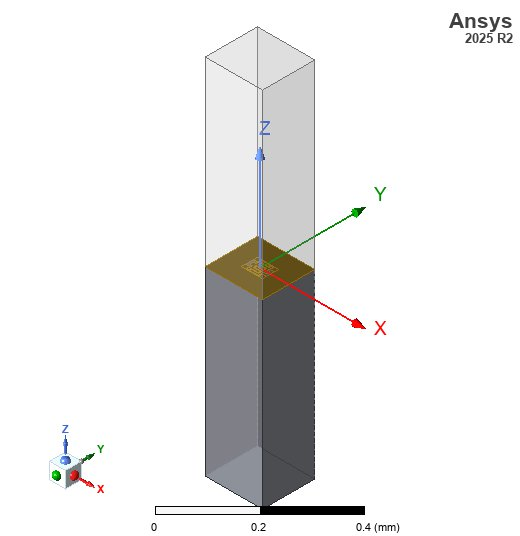

In [8]:
# Ensure HFSS model fits the screen
hfss.modeler.fit_all()

# Save screenshot
img_dir = PATH.repo / "docs" / "_static" / "images"
img_dir.mkdir(parents=True, exist_ok=True)
hfss_img_path = img_dir / "hfss_driven_capacitor_geom.jpg"
hfss.post.export_model_picture(
    full_name=str(hfss_img_path), show_axis=True, show_grid=False, show_ruler=True
)

# Display in notebook
display(Image(filename=str(hfss_img_path)))

## Create Lumped Ports

Add lumped ports at both ends of the capacitor to measure S-parameters.
The ports are placed at the CPW feed locations.

In [9]:

print("Creating lumped ports.")

hfss_sim.add_lumped_ports(prepared_component.ports, cpw_gap, cpw_width)
for port in prepared_component.ports:
    print(
        f"  Created {port.name} at {port.center} with orientation {port.orientation}°"
    )

Creating lumped ports.
PyAEDT INFO: Boundary Lumped Port o1 has been created.


PyAEDT INFO: Boundary Lumped Port o2 has been created.


  Created o1 at (-23.0, 0.0) with orientation 180.0°
  Created o2 at (23.0, 0.0) with orientation 0.0°


## Configure Driven Modal Analysis

Set up the solution with frequency sweep to compute S-parameters
across the desired frequency range.

In [10]:
# Create driven modal setup
setup = hfss.create_setup(
    name="DrivenSetup",
    Frequency=f"{HFSS_CONFIG['solution_frequency_ghz']}GHz",
)

setup.props["MaxDeltaS"] = HFSS_CONFIG["max_delta_s"]
setup.props["MaximumPasses"] = HFSS_CONFIG["max_passes"]
setup.props["MinimumPasses"] = 2
setup.props["PercentRefinement"] = 30
setup.update()

# Create frequency sweep
sweep = setup.create_frequency_sweep(
    unit="GHz",
    name="FrequencySweep",
    start_frequency=HFSS_CONFIG["sweep_start_ghz"],
    stop_frequency=HFSS_CONFIG["sweep_stop_ghz"],
    sweep_type="Interpolating",
    num_of_freq_points=HFSS_CONFIG["sweep_points"],
)

print("Driven modal setup configured:")
print(f"  - Solution frequency: {HFSS_CONFIG['solution_frequency_ghz']} GHz")
print(
    f"  - Sweep range: {HFSS_CONFIG['sweep_start_ghz']} - {HFSS_CONFIG['sweep_stop_ghz']} GHz"
)
print(f"  - Number of points: {HFSS_CONFIG['sweep_points']}")

PyAEDT INFO: Linear count sweep FrequencySweep has been correctly created


Driven modal setup configured:
  - Solution frequency: 5.0 GHz
  - Sweep range: 0.1 - 20.0 GHz
  - Number of points: 401


## Run Simulation

Execute the driven modal analysis with frequency sweep.

In [11]:
print("Starting driven modal analysis...")
print("(This may take several minutes)")

# Save project before analysis
hfss.save_project()

# Run the analysis
start_time = time.time()
success = hfss.analyze_setup("DrivenSetup", cores=4)
elapsed = time.time() - start_time

if not success:
    print("\nERROR: HFSS simulation failed!")
else:
    print(f"Analysis completed in {elapsed:.1f} seconds")

Starting driven modal analysis...
(This may take several minutes)
PyAEDT INFO: Project idc_driven Saved correctly


PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/HFSS correctly changed.


PyAEDT INFO: Solving design setup DrivenSetup


PyAEDT INFO: Design setup DrivenSetup solved correctly in 0.0h 1.0m 21.0s


PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/HFSS correctly changed.


Analysis completed in 80.8 seconds


## Extract and Plot S-Parameters

Get the S-parameters from the simulation and visualize the results.

PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec


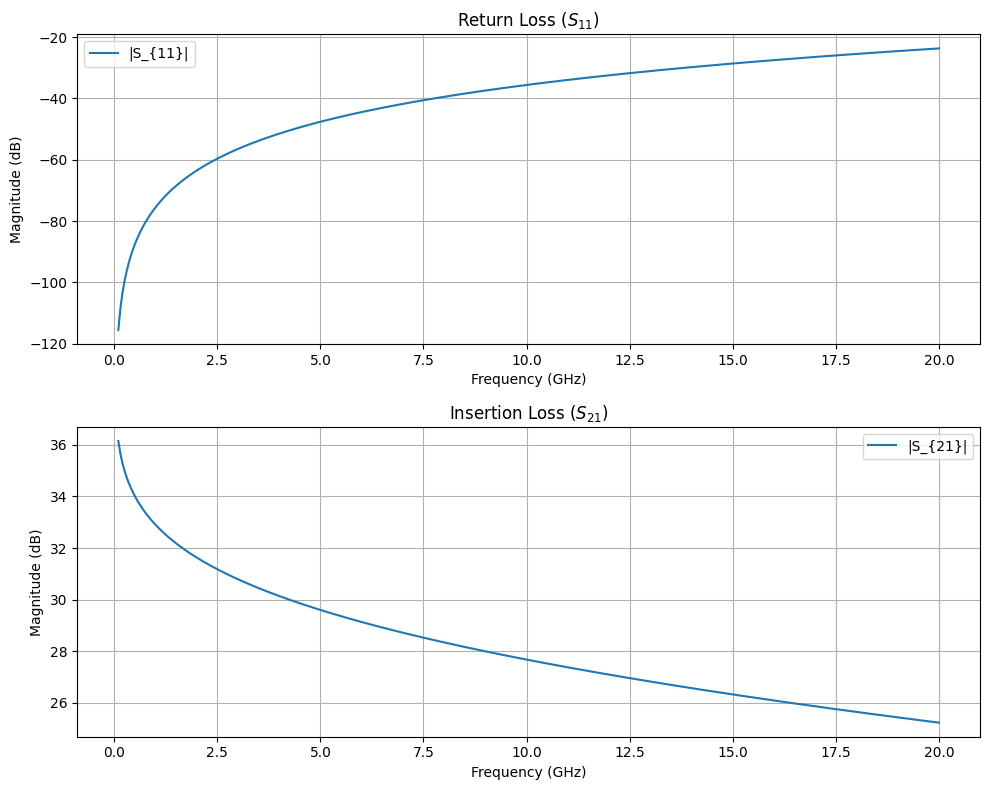

In [12]:
# Extract results using the wrapper
df_results = hfss_sim.get_sparameter_results(setup.name, sweep.name)

frequencies_ghz = df_results["frequency_ghz"].to_numpy()

# Plot S-parameters
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Filter for S11 and S21 type traces
s11_col = next(col for col in df_results.columns if "S(o1:1,o1:1)" in col)
s21_col = next(col for col in df_results.columns if "S(o2:1,o1:1)" in col)

s11_trace = df_results[s11_col].to_numpy().astype(np.complex128)
s21_trace = df_results[s21_col].to_numpy().astype(np.complex128)

s11_mag_db = 20 * np.log10(np.abs(s11_trace))
s21_mag_db = 20 * np.log10(np.abs(s21_trace))

axes[0].plot(frequencies_ghz, s11_mag_db, label=r"|S_{11}|")
axes[1].plot(frequencies_ghz, s21_mag_db, label=r"|S_{21}|")

axes[0].set_xlabel("Frequency (GHz)")
axes[0].set_ylabel("Magnitude (dB)")
axes[0].set_title("Return Loss ($S_{11}$)")
axes[0].grid(True)
axes[0].legend()

axes[1].set_xlabel("Frequency (GHz)")
axes[1].set_ylabel("Magnitude (dB)")
axes[1].set_title("Insertion Loss ($S_{21}$)")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
# plt.show()

## Plot Field Solution

We can visualize the electric field magnitude on the surface of the substrate
to see the capacitive coupling between the interdigital fingers.

![HFSS field](../docs/_static/images/hfss_driven_capacitor_field.jpg)

PyAEDT INFO: Active Design set to InterdigitalCapacitor


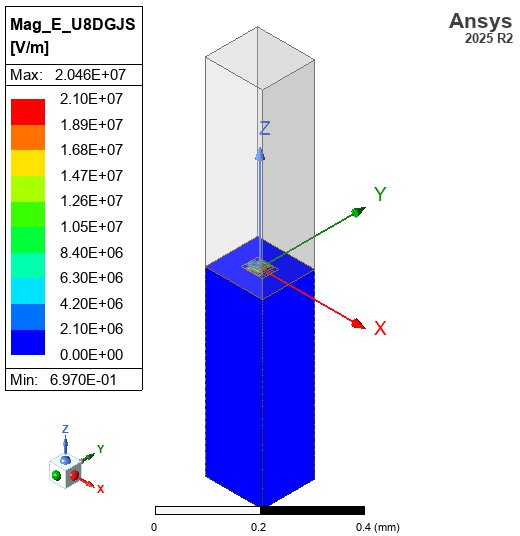

In [13]:
# Ensure the model fits the screen
hfss.modeler.fit_all()

# Create a surface field plot of the electric field magnitude on the substrate
plot = hfss.post.create_fieldplot_surface(
    assignment=[substrate_name], quantity="Mag_E", setup=f"{setup.name} : LastAdaptive"
)

# Export the field plot picture
hfss_field_img_path = img_dir / "hfss_driven_capacitor_field.jpg"
if plot:
    hfss.post.export_model_picture(
        full_name=str(hfss_field_img_path),
        show_axis=True,
        show_grid=False,
        show_ruler=True,
        field_selections="all",
    )
else:
    print("Failed to create field plot")

# Display in notebook
display(Image(filename=str(hfss_field_img_path)))

## Extract Capacitance from Admittance (Y-Parameters)

Relying only on the magnitude of $S_{21}$ assumes the geometry behaves identically
to a single perfect capacitor floating in a vacuum. In reality, the structure has
shunt parasitic capacitances to ground ($C_{11}$ and $C_{22}$) that skew the
$S_{21}$ magnitude.

The robust way to extract mutual capacitance is using Y-parameters (Admittance), see {cite:p}`m.pozarMicrowaveEngineering2012`.
In a Pi-network model, the mutual admittance $Y_{12}$ isolates the series element:

$$ Y_{12} = -j\omega C_{12} $$

Therefore, the exact mutual capacitance is:

$$ C_{12} = -\frac{\text{Im}(Y_{12})}{\omega} $$

In [14]:
# Extract Y21 parameter manually using PyAEDT's solution data
solution_y = hfss.post.get_solution_data(
    expressions="Y(o2:1,o1:1)", setup_sweep_name=f"{setup.name} : {sweep.name}"
)

# Parse complex Y-parameters
_, y_real = solution_y.get_expression_data(formula="real")
_, y_imag = solution_y.get_expression_data(formula="imag")
y21_trace = np.array(y_real) + 1j * np.array(y_imag)
frequencies_ghz_y = np.array(solution_y.primary_sweep_values)

# Analysis frequencies in GHz
analysis_frequencies_ghz = [1, 5, 10]

print("\n=== HFSS Capacitance Analysis ===")
print("-" * 40)
print(f"Analytical estimate: {C_estimate * 1e15:.2f} fF")
print("-" * 40)

C_hfss_values = {}
for freq_target in analysis_frequencies_ghz:
    idx = np.argmin(np.abs(frequencies_ghz_y - freq_target))
    freq_hz = frequencies_ghz_y[idx] * 1e9
    y21 = y21_trace[idx]

    ω = 2 * np.pi * freq_hz
    C_extracted = -np.imag(y21) / ω
    C_hfss_values[freq_target] = C_extracted

    print(
        f"At {freq_hz / 1e9:.2f} GHz: Y21 = {y21:.2e}, C ≈ {C_extracted * 1e15:.2f} fF"
    )
    print(
        f"Relative difference: {(float(C_estimate) - C_extracted) / float(C_estimate) * 100:.2f}%"
    )

PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec



=== HFSS Capacitance Analysis ===
----------------------------------------
Analytical estimate: 8.19 fF
----------------------------------------
At 1.00 GHz: Y21 = 5.76e-10-6.15e-05j, C ≈ 9.84 fF
Relative difference: -20.19%
At 4.98 GHz: Y21 = 1.43e-08-3.08e-04j, C ≈ 9.84 fF
Relative difference: -20.23%
At 10.00 GHz: Y21 = 5.73e-08-6.19e-04j, C ≈ 9.85 fF
Relative difference: -20.38%


## HFSS Cleanup

Close HFSS and clean up temporary files before starting Q3D.

In [15]:
# Save and close HFSS
hfss.save_project()
# hfss.release_desktop()
time.sleep(2)

# Clean up temp directory
temp_dir.cleanup()
print("HFSS session closed and temporary files cleaned up")

PyAEDT INFO: Project idc_driven Saved correctly


HFSS session closed and temporary files cleaned up


## Q3D Extractor Capacitance Extraction

Now we simulate the same geometry using Q3D Extractor, which solves
quasi-static electric fields to directly compute the capacitance matrix.

**Comparison of approaches:**
- **HFSS Driven Modal**: Full-wave solve → S-parameters → Y-parameters → $C_{12}$
- **Q3D Extractor**: Quasi-static solve → direct capacitance matrix
- **Analytical**: Conformal mapping model (no simulation)

Q3D is particularly well suited for parasitic capacitance extraction because
it directly solves the electrostatic (or quasi-static) problem, which is
faster and more accurate at low frequencies than extracting capacitance from
full-wave S-parameters.

**References:**
- Q3D Extractor: https://aedt.docs.pyansys.com/version/stable/API/_autosummary/ansys.aedt.core.q3d.Q3d.html

### Initialize Q3D Project

Set up a Q3D Extractor project for capacitance extraction.

```{note}
This code requires an Ansys AEDT license (same as HFSS above).
```

In [16]:
# Create temporary directory for Q3D project
temp_dir_q3d = tempfile.TemporaryDirectory(suffix=".ansys_qpdk_q3d")
project_path_q3d = Path(temp_dir_q3d.name) / "idc_q3d.aedt"


# Create temporary directory for Q3D project
temp_dir_q3d = tempfile.TemporaryDirectory(suffix=".ansys_qpdk_q3d")
project_path_q3d = Path(temp_dir_q3d.name) / "idc_q3d.aedt"

# Initialize Q3D Extractor
q3d = Q3d(
    project=str(project_path_q3d),
    design="InterdigitalCapacitor_Q3D",
    non_graphical=False,
    new_desktop=True,
    version="2025.2",
)
q3d.modeler.model_units = "um"

# Initialize Q3D wrapper
q3d_sim = Q3D(q3d)

print(f"Q3D project created: {q3d.project_file}")
print(f"Design name: {q3d.design_name}")
print(f"Solution type: {q3d.solution_type}")

PyAEDT INFO: Python version 3.12.13 (main, Mar  3 2026, 14:59:34) [Clang 21.1.4 ].


PyAEDT INFO: PyAEDT version 0.26.2.


PyAEDT INFO: Returning found Desktop session with PID 118106!


PyAEDT INFO: Project idc_q3d has been created.


PyAEDT INFO: Added design 'InterdigitalCapacitor_Q3D' of type Q3D Extractor.


PyAEDT INFO: AEDT objects correctly read


PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 0sec


Q3D project created: /tmp/tmp_vdfv0r7.ansys_qpdk_q3d/idc_q3d.aedt
Design name: InterdigitalCapacitor_Q3D
Solution type: Q3D Extractor


### Import Geometry and Assign Signal Nets

Import the same prepared component into Q3D and assign signal nets
based on port locations. Each port becomes a separate conductor
in the capacitance matrix.

The `q3d_sim.assign_nets_from_ports` method is the Q3D equivalent
of `hfss_sim.add_lumped_ports` — it maps gdsfactory port locations to
Q3D conductor nets.

In [17]:

# Import the prepared component geometry into Q3D
conductor_objects = q3d_sim.import_component(prepared_component)
print(f"Imported {len(conductor_objects)} conductor objects: {conductor_objects}")

# Add substrate below the component (Q3D modeler API is compatible with HFSS)
substrate_q3d_name = q3d_sim.add_substrate(
    prepared_component,
    thickness=500.0,
    material="silicon",
)
print(f"Created substrate: {substrate_q3d_name}")

PyAEDT INFO: GDS layer imported with elevations and thickness.


PyAEDT INFO: Materials class has been initialized! Elapsed time: 0m 0sec


Imported 7 conductor objects: ['M1_4', 'M1_3', 'M1_6', 'M1_7', 'M1_5', 'M1_1', 'M1_2']
Created substrate: Substrate


In [18]:
# Assign signal nets from port locations
signal_nets = q3d_sim.assign_nets_from_ports(
    prepared_component.ports, conductor_objects
)
print(f"Assigned signal nets: {signal_nets}")

PyAEDT INFO: 3 Nets have been identified: M1_1, M1_3, M1_4


Assigned signal nets: ['o1', 'o2']


### Q3D Geometry Verification
Here is the 3D geometry of the interdigital capacitor in Q3D Extractor.

![Q3D geometry](../docs/_static/images/q3d_driven_capacitor_geom.jpg)

PyAEDT INFO: Parsing /tmp/tmp_vdfv0r7.ansys_qpdk_q3d/idc_q3d.aedt.


PyAEDT INFO: File /tmp/tmp_vdfv0r7.ansys_qpdk_q3d/idc_q3d.aedt correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: aedt file load time 0.002794027328491211


PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec


PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 0sec


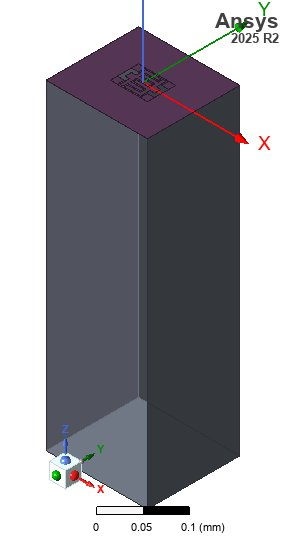

In [19]:
# Ensure Q3D model fits the screen
q3d.modeler.fit_all()

# Save screenshot
img_dir = PATH.repo / "docs" / "_static" / "images"
img_dir.mkdir(parents=True, exist_ok=True)
q3d_img_path = img_dir / "q3d_driven_capacitor_geom.jpg"
q3d.post.export_model_picture(
    full_name=str(q3d_img_path), show_axis=True, show_grid=False, show_ruler=True
)

# Display in notebook
display(Image(filename=str(q3d_img_path)))

### Configure and Run Q3D Analysis

Set up a Q3D adaptive analysis at the same frequency used for HFSS.
Q3D solves the quasi-static field problem and computes the full
capacitance matrix between all signal nets.

In [20]:
# Create Q3D setup
q3d_setup = q3d.create_setup(name="Q3DSetup")
q3d_setup.props["AdaptiveFreq"] = f"{HFSS_CONFIG['solution_frequency_ghz']}GHz"
q3d_setup.props["Cap"]["MaxPass"] = 17
q3d_setup.props["Cap"]["MinPass"] = 2
q3d_setup.props["Cap"]["PerError"] = 0.5
# Disable AC and DC solving to avoid source/sink errors
q3d_setup.ac_rl_enabled = False
q3d_setup.dc_enabled = False
q3d_setup.capacitance_enabled = True
q3d_setup.update()

print("Q3D setup configured:")
print(f"  - Adaptive frequency: {HFSS_CONFIG['solution_frequency_ghz']} GHz")

Q3D setup configured:
  - Adaptive frequency: 5.0 GHz


In [21]:
print("Starting Q3D analysis...")
print("(This is typically faster than full-wave HFSS)")

q3d.save_project()

start_time_q3d = time.time()
success_q3d = q3d.analyze_setup("Q3DSetup", cores=4)
elapsed_q3d = time.time() - start_time_q3d

if not success_q3d:
    print("\nERROR: Q3D simulation failed!")
    m = q3d.desktop_class.odesktop.GetMessages(q3d.project_name, q3d.design_name, 0)
    for msg in m:
        print(f"Desktop Msg: {msg}")
else:
    print(f"Q3D analysis completed in {elapsed_q3d:.1f} seconds")

Starting Q3D analysis...
(This is typically faster than full-wave HFSS)
PyAEDT INFO: Project idc_q3d Saved correctly


PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/Q3D Extractor correctly changed.


PyAEDT INFO: Solving design setup Q3DSetup


PyAEDT INFO: Design setup Q3DSetup solved correctly in 0.0h 1.0m 2.0s


PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/Q3D Extractor correctly changed.


Q3D analysis completed in 61.7 seconds


### Extract Q3D Capacitance Matrix

Q3D directly outputs the capacitance matrix between all signal nets.
The off-diagonal element $C_{12}$ gives the mutual capacitance, which
corresponds to the coupling capacitance of the interdigital capacitor.

In [22]:
# Extract the capacitance matrix using the wrapper
cap_df = q3d_sim.get_capacitance_matrix(setup_name="Q3DSetup")
print("Q3D Capacitance Matrix (F):")
print(cap_df)

# Extract mutual capacitance |C12| from the off-diagonal element
C_q3d = None
for col in cap_df.columns:
    # Match off-diagonal entries exactly between o1 and o2
    if col in {"C(o1,o2)", "C(o2,o1)"}:
        C_q3d = abs(float(cap_df[col][0]))
        break

if C_q3d is not None:
    print(f"\nQ3D mutual capacitance |C₁₂|: {C_q3d * 1e15:.2f} fF")

PyAEDT WARNING: No report category provided. Automatically identified Matrix


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec


PyAEDT WARNING: No report category provided. Automatically identified Matrix


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec


...

PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec


PyAEDT WARNING: No report category provided. Automatically identified Matrix


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec


Q3D Capacitance Matrix (F):
shape: (1, 6)
┌──────────────┬─────────────┬─────────────┬────────────┬─────────────┬────────────┐
│ C(M1_1,M1_1) ┆ C(M1_1,o1)  ┆ C(M1_1,o2)  ┆ C(o1,o1)   ┆ C(o1,o2)    ┆ C(o2,o2)   │
│ ---          ┆ ---         ┆ ---         ┆ ---        ┆ ---         ┆ ---        │
│ f64          ┆ f64         ┆ f64         ┆ f64        ┆ f64         ┆ f64        │
╞══════════════╪═════════════╪═════════════╪════════════╪═════════════╪════════════╡
│ 2.8507e-14   ┆ -9.2535e-15 ┆ -9.2194e-15 ┆ 1.8289e-14 ┆ -8.7666e-15 ┆ 1.8264e-14 │
└──────────────┴─────────────┴─────────────┴────────────┴─────────────┴────────────┘

Q3D mutual capacitance |C₁₂|: 8.77 fF


### Q3D Cleanup

In [23]:
q3d.save_project()
# q3d.release_desktop()
time.sleep(2)

temp_dir_q3d.cleanup()
print("Q3D session closed and temporary files cleaned up")

PyAEDT INFO: Project idc_q3d Saved correctly


Q3D session closed and temporary files cleaned up


## Comparison: Analytical vs HFSS vs Q3D

Compare the capacitance values obtained from all three methods.
The analytical model provides a quick estimate, the HFSS driven modal
simulation gives the full-wave result, and Q3D Extractor provides
a direct quasi-static capacitance extraction.

In [24]:
print("\n" + "=" * 58)
print("          Capacitance Comparison Summary")
print("=" * 58)
print(f"{'Method':<28} {'C (fF)':>10} {'Δ vs Analytical':>16}")
print("-" * 58)

C_analytical_fF = float(C_estimate) * 1e15
print(f"{'Analytical':<28} {C_analytical_fF:>10.2f} {'(reference)':>16}")

for freq_ghz, c_val in C_hfss_values.items():
    c_fF = c_val * 1e15
    delta = (c_val - float(C_estimate)) / float(C_estimate) * 100
    label = f"HFSS @ {freq_ghz} GHz"
    print(f"{label:<28} {c_fF:>10.2f} {delta:>+15.1f}%")

if C_q3d is not None:
    C_q3d_fF = C_q3d * 1e15
    delta_q3d = (C_q3d - float(C_estimate)) / float(C_estimate) * 100
    print(f"{'Q3D Extractor':<28} {C_q3d_fF:>10.2f} {delta_q3d:>+15.1f}%")

print("=" * 58)


          Capacitance Comparison Summary
Method                           C (fF)  Δ vs Analytical
----------------------------------------------------------
Analytical                         8.19      (reference)
HFSS @ 1 GHz                       9.84           +20.2%
HFSS @ 5 GHz                       9.84           +20.2%
HFSS @ 10 GHz                      9.85           +20.4%
Q3D Extractor                      8.77            +7.1%


## Summary

This notebook demonstrated three approaches for characterizing an interdigital
capacitor:

1. **Analytical Estimate**: Using the conformal mapping model for interdigital
   capacitors to get a quick capacitance estimate without simulation

2. **HFSS Driven Modal Simulation**:
   - Created the component geometry with QPDK and imported it into HFSS
   - Added lumped ports at CPW feed locations for S-parameter measurements
   - Ran a frequency sweep and extracted capacitance from Y-parameters
   ($C_{12} = -\text{Im}(Y_{12}) / \omega$)

3. **Q3D Extractor Simulation**:
   - Imported the same geometry into Q3D Extractor
   - Assigned signal nets from gdsfactory port locations
   - Directly computed the capacitance matrix via quasi-static field solution

**Key Takeaways:**
- Q3D Extractor directly solves for capacitance, making it ideal for
  parasitic extraction at low frequencies
- HFSS driven modal captures frequency-dependent effects (parasitic
  inductance, radiation) that Q3D's quasi-static approach does not
- The analytical model provides a useful sanity check for both simulations
- All three methods should agree well at low frequencies where the structure
  is electrically small


## References

```{bibliography}
:filter: docname in docnames
```